# Markerless Motion Capture Validation — MediaPipe Results

Brings together the full MediaPipe validation against ground truth (force plates
and optical motion capture), reproducing the structure of the original OpenPose
results notebook. Each section computes one task family's metrics and appends to
`result_dataframes`; the final cell concatenates everything into one table.

**Run order matters** — the DJ cell produces flight/contact frames used in the
Temporal section, so run top to bottom.

## Imports & setup

In [1]:
import glob, os
import numpy as np
import pandas as pd
from utilities import utils
from tasks import cmj, dj, velocity, rjt, hip, nordic, slr, sls
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

def load_task(folder, drop_ul=False, only_ul=False):
    files = sorted(p for p in glob.glob(f"data/keypoints/{folder}/*.txt")
                   if "world" not in p.lower())
    if drop_ul: files = [p for p in files if "UL" not in p.upper()]
    if only_ul: files = [p for p in files if "UL" in p.upper()]
    return files

result_dataframes = []

## 1 · Jump Height

Countermovement jump (CMJ) and drop jump (DJ), validated against force plates.

In [2]:
# data
cmj_data = utils.read_list('cmj_data')
dj_data  = utils.read_list('dj_data')

# CMJ files. If your CMJ set has unilateral captures, split them out into
# cmj_ul_files; otherwise leave it empty for bilateral-only.
cmj_bl_files = load_task("cmj")
cmj_ul_files = []        # e.g. load_task("cmj", only_ul=True) if you have UL files

In [4]:
import os
files = sorted(os.path.basename(p) for p in load_task("cmj"))
for f in files: print(f)

P03_CMJBL_FRONT.txt
P03_CMJUL_FRONT.txt
P04_CMJ_BL_FRONT.txt
P04_CMJ_UL_FRONT.txt
P05_CMJ_BL_FRONT.txt
P05_CMJ_UL_FRONT.txt
P06_CMJ_BL_FRONT.txt
P06_CMJ_UL_FRONT.txt
P07_CMJ_BL_FRONT.txt
P07_CMJ_UL_FRONT.txt
P08_CMJ_BL_FRONT.txt
P08_CMJ_UL_FRONT.txt
P09_CMJ_BL_FRONT.txt
P09_CMJ_UL_FRONT.txt
P10_CMJ_BL_FRONT.txt
P10_CMJ_UL_FRONT.txt
P11_CMJ_BL_FRONT.txt
P11_CMJ_UL_FRONT.txt
P12_CMJ_BL_FRONT.txt
P12_CMJ_UL_FRONT.txt
P13_CMJ_BL_FRONT.txt
P13_CMJ_UL_FRONT.txt
P14_CMJ_BL_FRONT.txt
P14_CMJ_UL_FRONT.txt
P15_CMJ_BL_FRONT.txt
P15_CMJ_UL_FRONT.txt
P16_CMJ_BL_FRONT.txt
P16_CMJ_UL_FRONT.txt
P17_CMJ_BL_FRONT.txt
P17_CMJ_UL_FRONT.txt
P18_CMJ_BL_FRONT.txt
P18_CMJ_UL_FRONT.txt


In [5]:
cmj_bl_files = sorted(p for p in load_task("cmj") if "<BL_TOKEN>" in p.upper())
cmj_ul_files = sorted(p for p in load_task("cmj") if "<UL_TOKEN>" in p.upper())

[assemble_jumps] subject not in all three sources: ['P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18']
[assemble_jumps] no subjects survived the join -- returning empty frame. If ptm='gravity', this usually means the PTM.mm_per_px fit produced NaNs.
[assemble_jumps] subject not in all three sources: ['P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18']
[assemble_jumps] no subjects survived the join -- returning empty frame. If ptm='gravity', this usually means the PTM.mm_per_px fit produced NaNs.


ValueError: Axis limits cannot be NaN or Inf

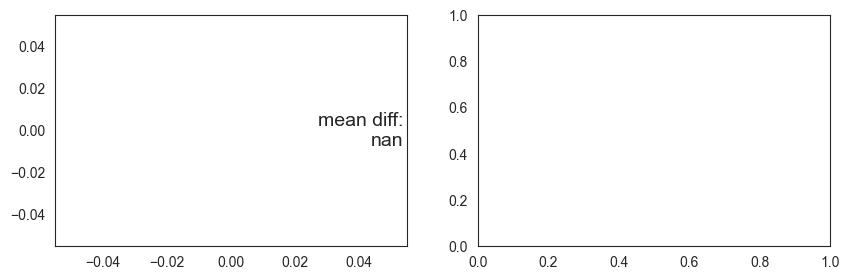

In [6]:
# CMJ — height & gravity PTM
all_jumps_h = cmj.assemble_jumps(cmj_bl_files, cmj_ul_files, cmj_data,
                                 ptm='height', trim_first_ul={'P17','P11'})
all_jumps_g = cmj.assemble_jumps(cmj_bl_files, cmj_ul_files, cmj_data,
                                 ptm='gravity', trim_first_ul={'P17','P11'})
cmj.ba_plots(all_jumps_h, title='height PTM')
cmj_h = cmj.get_metrics(all_jumps_h, ptm='height')
cmj_g = cmj.get_metrics(all_jumps_g, ptm='gravity')
pd.concat([cmj_h, cmj_g], ignore_index=True)

In [ ]:
# DJ — returns (jump_height, flight_time, contact_time) frames
dj_bl = load_task("dj", drop_ul=True)
dj_ul = load_task("dj", only_ul=True)
dj_jh, dj_ft, dj_ct = dj.get_metrics(dj_bl, dj_ul, dj_data, ptm='height')
dj_jh

In [ ]:
result_dataframes.extend([cmj_h, cmj_g, dj_jh])

## 2 · Velocity-Based Tests

Back squat & overhead press, mean and peak velocity, validated against optical
motion capture. Height and barbell pixel-to-metric scaling.

In [ ]:
bsq = load_task("bsq"); ohp = load_task("ohp")
bsq_data = utils.read_list('bsq_data'); ohp_data = utils.read_list('ohp_data')

bsq_h = velocity.get_metrics(bsq, bsq_data, task='bsq', task_label='Back Squat', ptm='height')
bsq_b = velocity.get_metrics(bsq, bsq_data, task='bsq', task_label='Back Squat', ptm='barbell')
ohp_h = velocity.get_metrics(ohp, ohp_data, task='ohp', task_label='Overhead Press', ptm='height')
ohp_b = velocity.get_metrics(ohp, ohp_data, task='ohp', task_label='Overhead Press', ptm='barbell')

result_dataframes.extend([bsq_h, bsq_b, ohp_h, ohp_b])
pd.concat([bsq_h, bsq_b, ohp_h, ohp_b], ignore_index=True)

## 3 · Temporal Metrics

Flight time & contact time for the drop jump (computed in §1) and the repeated
jump test (RJT), validated against force plates.

In [ ]:
rjt_files = load_task("rjt")
rjt_data  = utils.read_list('rjt_data')
rjt_m = rjt.get_metrics(rjt_files, rjt_data, ptm='height')

# dj_ft, dj_ct come from the DJ cell in section 1
result_dataframes.extend([dj_ft, dj_ct, rjt_m])
pd.concat([dj_ft, dj_ct, rjt_m], ignore_index=True)

## 4 · Angular Metrics

Joint-angle range of motion (and angular velocity where applicable) for the
Nordic curl, straight-leg raise, single-leg squat, and hip rotations, validated
against optical motion capture. Angles are scale-invariant → PTM Ref = N/A.

Note: `hip.get_metrics` takes the keypoints **folder path**, not a file list.

In [ ]:
nordic_data = utils.read_list('nordic_data')
slr_data    = utils.read_list('slr_data')
sls_data    = utils.read_list('sls_data')
hip_data    = utils.read_list('hip_data')

nordic_m = nordic.get_metrics(load_task("nordic"), nordic_data)
slr_m    = slr.get_metrics(load_task("slr"), slr_data)
sls_m    = sls.get_metrics(load_task("slsq"), sls_data)
hip_m    = hip.get_metrics("data/keypoints/hip", hip_data)

result_dataframes.extend([nordic_m, slr_m, sls_m, hip_m])
pd.concat([nordic_m, slr_m, sls_m, hip_m], ignore_index=True)

## 5 · Combined Results Table

Every task and metric in one table, mirroring the published OpenPose results.

In [ ]:
final = pd.concat(result_dataframes, ignore_index=True)
cols = ['Metric','Task','PTM Ref','Ground Truth','MAE','Reliability','ICC']
final = final[[c for c in cols if c in final.columns]]
final

In [ ]:
os.makedirs("results", exist_ok=True)
final.to_csv("results/mediapipe_results.csv", index=False)
print("saved results/mediapipe_results.csv —", len(final), "rows")